# ICE Analytics - Product Activity Analysis

**Objetivo:** Analizar el dataset de actividad de producto, limpiar inconsistencias, calcular métricas de engagement y extraer señales para decisiones de producto.

**Dataset:** `product_activity.csv` — Cada fila representa actividad asociada a un post (evento).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('product_activity.csv')
raw_rows = len(df)
print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")

Dataset cargado: 8782 filas x 12 columnas


## 1. Exploración Inicial (Medir antes de limpiar)

In [3]:
df.head(10)

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile
5,U00488,2025-03-19T16:56:05,US,free,43.0,P0002030,finance,2025-03-28T12:10:25,3,10,9,web
6,U00480,2024-07-29T02:09:07,US,free,26.0,P0002003,life,2024-08-27T10:38:58,5,6,29,web
7,U01863,2024-12-12T21:40:02,CL,free,31.0,P0008000,health,2025-02-02T21:09:32,5,5,52,mobile
8,U00819,2024-04-26T02:18:59,BR,free,26.0,P0003544,health,2024-07-28T05:48:12,1,29,93,mobile
9,U00880,2024-12-12T23:03:33,UY,free,32.0,P0003784,science,2024-12-19T17:52:17,7,2,7,mobile


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


In [5]:
df.describe()

,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


In [6]:
# Conteo de nulos por columna
print("=== NULOS POR COLUMNA ===")
print(df.isnull().sum())
print(f"\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()}")

print(f"\n=== DUPLICADOS EXACTOS ===")
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")

=== NULOS POR COLUMNA ===
user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64

Total de filas con al menos un nulo: 754

=== DUPLICADOS EXACTOS ===
Filas duplicadas exactas: 172


In [7]:
# Valores únicos y frecuencias de columnas categóricas
print("=== PLAN_TYPE (valores únicos) ===")
print(df['plan_type'].value_counts())
print(f"\n=== POST_CATEGORY (valores únicos) ===")
print(df['post_category'].value_counts())
print(f"\n=== DEVICE_TYPE (valores únicos) ===")
print(df['device_type'].value_counts())

=== PLAN_TYPE (valores únicos) ===
plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64

=== POST_CATEGORY (valores únicos) ===
post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports          

In [8]:
# Chequeos lógicos de fechas
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce')
df['post_created_at_dt'] = pd.to_datetime(df['post_created_at'], errors='coerce')

# Posts que ocurren antes del signup
posts_before_signup = (df['post_created_at_dt'] < df['created_at_dt']).sum()
print(f"Posts con fecha anterior al signup: {posts_before_signup}")

# Fechas no parseables
print(f"created_at no parseables (NaT): {df['created_at_dt'].isna().sum()}")
print(f"post_created_at no parseables (NaT): {df['post_created_at_dt'].isna().sum()}")

# Chequeo de days_since_signup
df['days_since_signup_calc'] = (df['post_created_at_dt'] - df['created_at_dt']).dt.days
mismatch = (df['days_since_signup_calc'] != df['days_since_signup']) & df['days_since_signup_calc'].notna()
print(f"\ndays_since_signup inconsistentes: {mismatch.sum()} de {len(df)} ({mismatch.mean()*100:.1f}%)")

# Muestra de mismatches
print("\nEjemplos de mismatches (original vs calculado):")
df[mismatch][['user_id', 'created_at', 'post_created_at', 'days_since_signup', 'days_since_signup_calc']].head(5)

Posts con fecha anterior al signup: 100
created_at no parseables (NaT): 1
post_created_at no parseables (NaT): 1

days_since_signup inconsistentes: 4477 de 8782 (51.0%)

Ejemplos de mismatches (original vs calculado):


,user_id,created_at,post_created_at,days_since_signup,days_since_signup_calc
5,U00488,2025-03-19T16:56:05,2025-03-28T12:10:25,9,8.0
7,U01863,2024-12-12T21:40:02,2025-02-02T21:09:32,52,51.0
9,U00880,2024-12-12T23:03:33,2024-12-19T17:52:17,7,6.0
17,U01956,2025-02-19T10:47:45,2025-04-28T01:34:08,68,67.0
18,U01179,2024-08-28T23:29:24,2024-09-14T18:31:09,17,16.0


## 2. Limpieza Básica con Criterio

### Estrategia de limpieza:
1. **Remover duplicados exactos**
2. **Normalizar categóricas** (`plan_type`, `post_category`, `device_type`) → mapeo con diccionario canónico en un solo loop
3. **Convertir fechas** a datetime y reportar no parseables
4. **Recalcular `days_since_signup_calc`** y usar el calculado
5. **Quarantine**: separar filas con errores duros iterando sobre una lista de (máscara, razón)

In [9]:
# Paso 1: Remover duplicados exactos
rows_before = len(df)
df = df.drop_duplicates()
dupes_removed = rows_before - len(df)
print(f"Duplicados removidos: {dupes_removed} | Filas restantes: {len(df)}")

Duplicados removidos: 172 | Filas restantes: 8610


In [10]:
# Paso 2-4: Normalización canónica de plan_type, post_category y device_type
# ───────────────────────────────────────────────────────────────────────
# Para cada columna categórica:
#   1. strip() + lower() para limpiar espacios y mayúsculas
#   2. Mapear contra un diccionario canónico (incluye typos conocidos)
#   3. Lo que no matchea queda como NaN → irá a quarantine después
# ───────────────────────────────────────────────────────────────────────

canonical_maps = {
    'plan_type': {
        'free': 'free', 'pro': 'pro', 'enterprise': 'enterprise'
    },
    'post_category': {
        'tech': 'tech', 'life': 'life', 'sports': 'sports', 'science': 'science',
        'finance': 'finance', 'gaming': 'gaming', 'music': 'music', 'health': 'health',
        'education': 'education', 'travel': 'travel',
        # Typos conocidos
        'tehc': 'tech', 'sport': 'sports', 'sporst': 'sports', 'sp0rts': 'sports',
        'sciense': 'science', 'gamming': 'gaming', 'finanse': 'finance',
        'educatoin': 'education', 'healt': 'health', 'lfe': 'life',
        'trvael': 'travel', 'musc': 'music',
    },
    'device_type': {
        'web': 'web', 'mobile': 'mobile', 'phone': 'mobile', 'desktop': 'desktop'
    }
}

for col, mapping in canonical_maps.items():
    df[f'{col}_clean'] = df[col].str.strip().str.lower().map(mapping)
    n_invalid = df[f'{col}_clean'].isna().sum()
    print(f"{col}: {n_invalid} valores fuera de diccionario")
    if n_invalid > 0:
        print(f"  No mapeados: {df[df[f'{col}_clean'].isna()][col].value_counts().to_dict()}")
    print(f"  Distribución limpia: {df[f'{col}_clean'].value_counts().to_dict()}\n")

plan_type: 3 valores fuera de diccionario
  No mapeados: {'premium': 1, 'vip': 1, 'enterprise+': 1}
  Distribución limpia: {'free': 6637, 'pro': 1631, 'enterprise': 339}

post_category: 2 valores fuera de diccionario
  No mapeados: {'politics': 1, 'mistery': 1}
  Distribución limpia: {'tech': 1397, 'life': 1039, 'sports': 1028, 'science': 882, 'finance': 865, 'gaming': 844, 'education': 687, 'music': 685, 'health': 681, 'travel': 500}

device_type: 2 valores fuera de diccionario
  No mapeados: {'tablet': 1, 'console': 1}
  Distribución limpia: {'web': 4328, 'mobile': 3689, 'desktop': 591}



In [ ]:
# Paso 5 y 6: Fechas y recálculo de days_since_signup
# Las columnas datetime ya fueron creadas en la exploración
# Recalculamos days_since_signup_calc para el DF sin duplicados
df['days_since_signup_calc'] = (df['post_created_at_dt'] - df['created_at_dt']).dt.days

print("Comparación days_since_signup original vs calculado:")
comparison = pd.DataFrame({
    'original': df['days_since_signup'].describe(),
    'calculado': df['days_since_signup_calc'].describe()
})
print(comparison)

mismatch_mask = (df['days_since_signup_calc'] != df['days_since_signup']) & df['days_since_signup_calc'].notna()
print(f"\nMismatches: {mismatch_mask.sum()} ({mismatch_mask.mean()*100:.1f}%)")
print("-> Se usará days_since_signup_calc (calculado) para todo el análisis.")

In [ ]:
# Paso 7: Quarantine - Separar filas con errores duros
# ───────────────────────────────────────────────────────────────────────
# Se define una lista de (máscara, razón) y se itera sobre ella.
# Cada fila que cumpla alguna condición va a quarantine con su reason_code.
# Una fila puede tener múltiples razones (se concatenan con coma).
# ───────────────────────────────────────────────────────────────────────

checks = [
    (df['post_created_at_dt'] < df['created_at_dt'], 'post_before_signup'),
    (df['created_at_dt'].isna(), 'created_at_not_parseable'),
    (df['post_created_at_dt'].isna(), 'post_created_at_not_parseable'),
    (df['plan_type_clean'].isna(), 'plan_type_invalid'),
    (df['post_category_clean'].isna(), 'post_category_invalid'),
    (df['device_type_clean'].isna(), 'device_type_invalid'),
]

quarantine_reasons = []
for mask, reason in checks:
    for idx in df[mask].index:
        quarantine_reasons.append((idx, reason))

# Construir DataFrame de quarantine agrupando razones por fila
quarantine_df = pd.DataFrame(quarantine_reasons, columns=['original_index', 'reason_code'])
quarantine_indices = quarantine_df['original_index'].unique()

df_quarantine = df.loc[quarantine_indices].copy()
df_quarantine = df_quarantine.merge(
    quarantine_df.groupby('original_index')['reason_code'].apply(lambda x: ', '.join(x)).reset_index(),
    left_index=True, right_on='original_index'
)

df_clean = df.drop(index=quarantine_indices).copy()

print(f"Filas en quarantine: {len(quarantine_indices)}")
print(f"Filas en dataset limpio (CORE): {len(df_clean)}")
print(f"\nRazones de quarantine:")
print(quarantine_df['reason_code'].value_counts())

## 3. Data Quality Report

In [ ]:
# Data Quality Report
after_dedup = len(df)
core_rows = len(df_clean)
quarantine_rows = len(quarantine_indices)

report = pd.DataFrame({
    'Métrica': [
        'Filas RAW (originales)',
        'Duplicados exactos removidos',
        'Filas después de dedup',
        'Filas en Quarantine',
        'Filas CORE (limpias)',
        '% Quarantine',
        '% Mismatches en days_since_signup',
    ],
    'Valor': [
        raw_rows,
        dupes_removed,
        after_dedup,
        quarantine_rows,
        core_rows,
        f"{quarantine_rows / after_dedup * 100:.1f}%",
        f"{mismatch_mask.sum() / after_dedup * 100:.1f}%",
    ]
})

print("=" * 50)
print("        DATA QUALITY REPORT")
print("=" * 50)
print(report.to_string(index=False))
print("=" * 50)

## 4. Métricas y Análisis

> **Nota sobre unidad de análisis:** Cada fila es un **evento (post)**, no un usuario. Un usuario activo aparece en muchas filas. Esto significa que los promedios "por fila" están sesgados hacia usuarios con más posts. Es fundamental distinguir métricas a nivel de evento vs a nivel de usuario.

### 4.1 Distribuciones (Volumen)

Usuarios únicos por plan:
plan_type_clean
free          1546
pro            367
enterprise      82
Name: user_id, dtype: int64


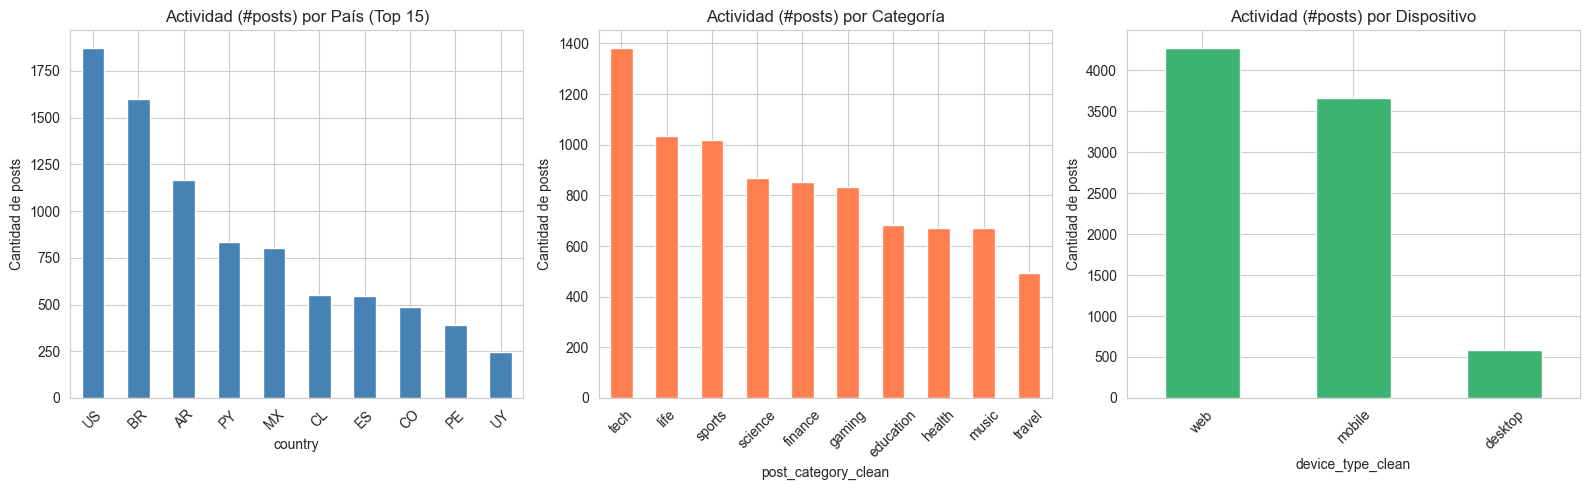

In [14]:
# Usuarios únicos por plan
users_by_plan = df_clean.groupby('plan_type_clean')['user_id'].nunique().sort_values(ascending=False)
print("Usuarios únicos por plan:")
print(users_by_plan)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Posts por país
df_clean.groupby('country').size().sort_values(ascending=False).head(15).plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Actividad (#posts) por País (Top 15)')
axes[0].set_ylabel('Cantidad de posts')
axes[0].tick_params(axis='x', rotation=45)

# Posts por categoría
df_clean['post_category_clean'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Actividad (#posts) por Categoría')
axes[1].set_ylabel('Cantidad de posts')
axes[1].tick_params(axis='x', rotation=45)

# Posts por dispositivo
df_clean['device_type_clean'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Actividad (#posts) por Dispositivo')
axes[2].set_ylabel('Cantidad de posts')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.2 Engagement (Votos)

In [ ]:
# Votos por plan: media, mediana, percentiles
votes_by_plan = df_clean.groupby('plan_type_clean')['votes_received'].agg(
    ['mean', 'median', 'std', 'count',
     lambda x: x.quantile(0.25),
     lambda x: x.quantile(0.75)]
)
votes_by_plan.columns = ['Media', 'Mediana', 'Std', 'N', 'P25', 'P75']
print("Votos por Plan:")
print(votes_by_plan.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Boxplot votos por plan
sns.boxplot(data=df_clean, x='plan_type_clean', y='votes_received', ax=axes[0],
            order=['free', 'pro', 'enterprise'])
axes[0].set_title('Votos por Plan')
axes[0].set_xlabel('Plan')
axes[0].set_ylabel('Votos recibidos')

# Votos por categoría
votes_by_cat = df_clean.groupby('post_category_clean')['votes_received'].median().sort_values(ascending=False)
votes_by_cat.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Mediana de Votos por Categoría')
axes[1].set_ylabel('Votos (mediana)')
axes[1].tick_params(axis='x', rotation=45)

# Votos por dispositivo
sns.boxplot(data=df_clean, x='device_type_clean', y='votes_received', ax=axes[2])
axes[2].set_title('Votos por Dispositivo')
axes[2].set_xlabel('Dispositivo')
axes[2].set_ylabel('Votos recibidos')

plt.tight_layout()
plt.show()

Votos por País (Top 10 por volumen):
         Media  Mediana     N
country                      
US        6.97      6.0  1873
BR        6.89      6.0  1600
AR        6.77      6.0  1168
PY        6.60      6.0   837
MX        6.96      6.0   802
CL        7.31      6.0   552
ES        6.98      6.0   547
CO        7.32      6.0   488
PE        6.55      6.0   393
UY        6.76      6.0   248


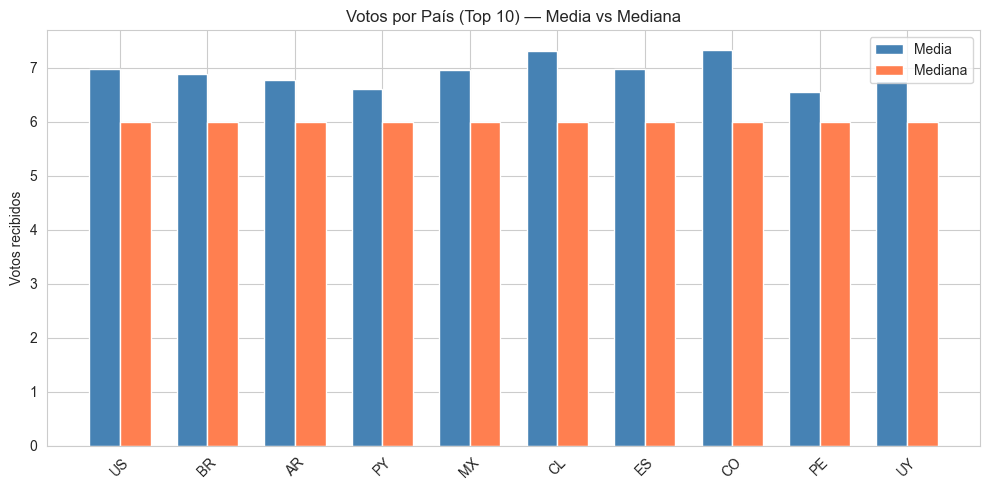

In [16]:
# Votos por país (top 10 por volumen)
votes_by_country = df_clean.groupby('country')['votes_received'].agg(['mean', 'median', 'count']).sort_values('count', ascending=False).head(10)
votes_by_country.columns = ['Media', 'Mediana', 'N']
print("Votos por País (Top 10 por volumen):")
print(votes_by_country.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(votes_by_country))
width = 0.35
ax.bar([i - width/2 for i in x], votes_by_country['Media'], width, label='Media', color='steelblue')
ax.bar([i + width/2 for i in x], votes_by_country['Mediana'], width, label='Mediana', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(votes_by_country.index, rotation=45)
ax.set_title('Votos por País (Top 10) — Media vs Mediana')
ax.set_ylabel('Votos recibidos')
ax.legend()
plt.tight_layout()
plt.show()